Setup libraries

In [63]:
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error , root_mean_squared_error
from sklearn.model_selection import cross_val_score

Read Data & present it in 5 different ways


In [64]:
data=pd.read_csv("house_prices.csv")
pd.set_option('display.max_columns', None)
data.head()


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [65]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [66]:
data.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [67]:
data.isna().mean().sort_values(ascending=False)


Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

In [68]:
data.shape

(187531, 21)

Fix the data

In [69]:
#remove duplicates
rows=len(data)
data=data.drop_duplicates()
print(f"removed {rows-len(data)} duplicated rows")

removed 0 duplicated rows


In [70]:
#missing values
missing=data.isnull().sum()
missing_per=(missing/len(data))*100

#clean table
missing_data=pd.DataFrame({
    'Missing Number': missing,
    'Missing percentage': missing_per.round(2),
})

missing_data[missing_data['Missing Number']>0].sort_values(by='Missing Number', ascending=False)

,Missing Number,Missing percentage
Plot Area,187531,100.00
Dimensions,187531,100.00
Society,109678,58.49
Super Area,107685,57.42
Car Parking,103357,55.11
overlooking,81436,43.43
Carpet Area,80673,43.02
facing,70233,37.45
Ownership,65517,34.94
Balcony,48935,26.09


Plotting

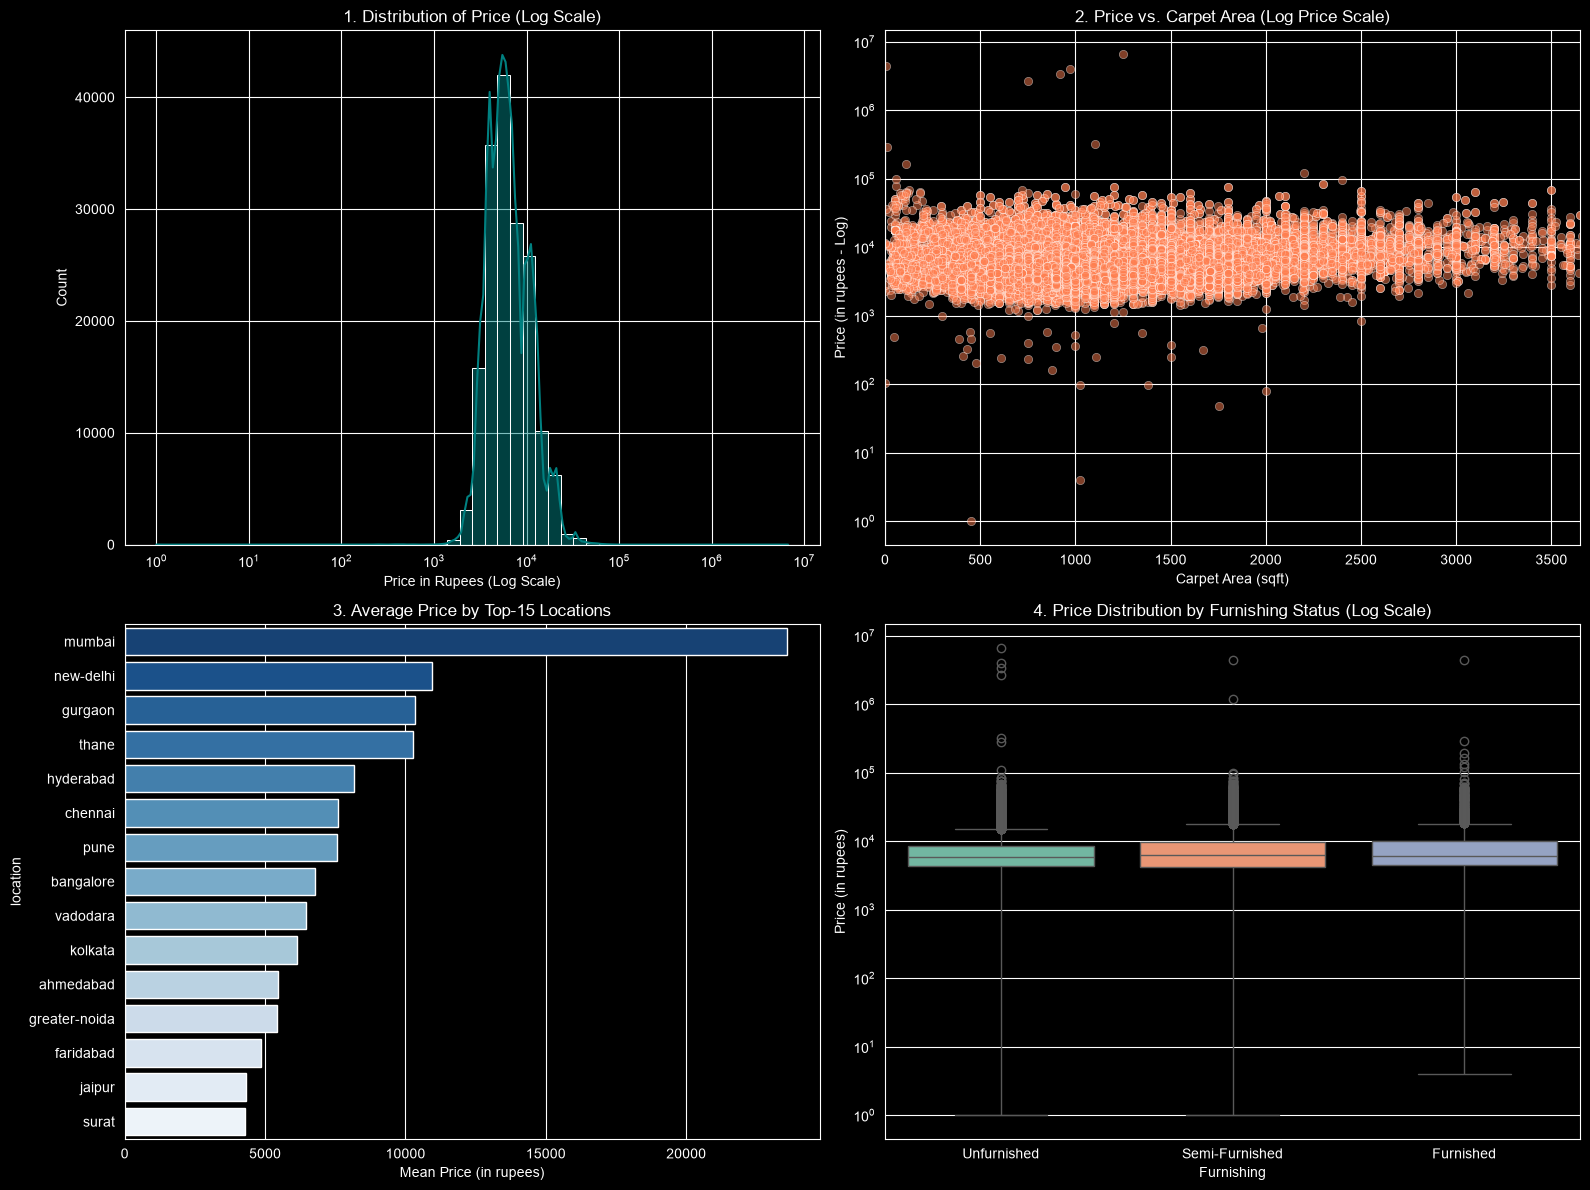

In [71]:
data['Carpet_Area_num'] = data['Carpet Area'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

# Filter for valid positive prices
valid_price_data = data[data['Price (in rupees)'] > 0].copy()

# Set up 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

#  Distribution of Target Price (Log Scale)
sns.histplot(valid_price_data['Price (in rupees)'], bins=50, kde=True, ax=axes[0, 0], color='teal', log_scale=True)
axes[0, 0].set_title('1. Distribution of Price (Log Scale)')
axes[0, 0].set_xlabel('Price in Rupees (Log Scale)')

# Price vs. Carpet Area (Scatter Plot with Log Price)
sns.scatterplot(data=valid_price_data, x='Carpet_Area_num', y='Price (in rupees)', ax=axes[0, 1], alpha=0.5, color='coral')
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('2. Price vs. Carpet Area (Log Price Scale)')
axes[0, 1].set_xlabel('Carpet Area (sqft)')
axes[0, 1].set_ylabel('Price (in rupees - Log)')
axes[0, 1].set_xlim(0, valid_price_data['Carpet_Area_num'].quantile(0.99))

# Average Price Top-15 Locations
top15_locs = valid_price_data['location'].value_counts().head(15).index
avg_price_loc = valid_price_data[valid_price_data['location'].isin(top15_locs)].groupby('location')['Price (in rupees)'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price_loc.values, y=avg_price_loc.index, ax=axes[1, 0], hue=avg_price_loc.index, palette='Blues_r', legend=False)
axes[1, 0].set_title('3. Average Price by Top-15 Locations')
axes[1, 0].set_xlabel('Mean Price (in rupees)')

# Price by Furnishing  (Boxplot)
sns.boxplot(data=valid_price_data, x='Furnishing', y='Price (in rupees)', ax=axes[1, 1], hue='Furnishing', palette='Set2', legend=False)
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('4. Price Distribution by Furnishing Status (Log Scale)')

plt.tight_layout()
plt.show()


In [72]:
data_clean=data.copy()

#analysis amount to numeric
def analysis_amount(x):
    if not isinstance(x,str):
        return None
    x=x.strip().lower()
    try:
        if"lac" in x:
            return float(x.replace("lac","").strip())* 1e5
        if "cr" in x:
            return float(x.replace("cr","").strip())* 1e5
        return float(x.replace(",","").strip())
    except ValueError:
        return None
data_clean["price_clean"]= data_clean["Amount(in rupees)"].apply(analysis_amount)
data_clean=data_clean.dropna(subset=['price_clean'])

In [73]:
#Area and normalization
def analysis_area(x):
    if not isinstance(x, str):
        return np.nan
    x = x.strip().lower()
    match = re.search(r'(\d+\.?\d*)', x)
    if not match:
        return np.nan
    val = float(match.group(1))
    if 'sqm' in x:
        return val * 10.764
    return val

# Prioritize Carpet Area, fall back to Super Area
data_clean['area_sqft'] = data_clean['Carpet Area'].apply(analysis_area)
if 'Super Area' in data_clean.columns:
    data_clean['area_sqft'] = data_clean['area_sqft'].fillna(data_clean['Super Area'].apply(analysis_area))

data_clean['area_sqft'] = data_clean['area_sqft'].fillna(data_clean['area_sqft'].median())

In [74]:
# Floor analyzation
def analysis_floor(x):
    if not isinstance(x, str):
        return 0
    x = x.strip().lower()
    if 'ground' in x:
        return 0
    if 'basement' in x:
        return -1
    match = re.search(r'^(\d+)', x)
    return int(match.group(1)) if match else 0

if 'Floor' in data_clean.columns:
    data_clean['floor_num'] = data_clean['Floor'].apply(analysis_floor)

In [75]:
#Bathroom / Balcony / Car Parking numeric conversion
for col in ['Bathroom', 'Balcony', 'Car Parking']:
    if col in data_clean.columns:
        data_clean[col] = data_clean[col].astype(str).str.extract(r'(\d+)').astype(float)
        data_clean[col] = data_clean[col].fillna(0)

In [76]:
# High-cardinality categories

if 'location' in data_clean.columns:
    top_50_locs = data_clean['location'].value_counts().head(50).index
    data_clean['location_grouped'] = data_clean['location'].apply(lambda x: x if x in top_50_locs else 'other')

if 'Society' in data_clean.columns:
    top_50_soc = data_clean['Society'].value_counts().head(50).index
    data_clean['society_grouped'] = data_clean['Society'].apply(lambda x: x if x in top_50_soc else 'other')

In [77]:
#Drop  empty columns
drop_cols = ['Index', 'Title', 'Description', 'Dimensions']
data_clean = data_clean.drop(columns=[c for c in drop_cols if c in data_clean.columns])


# Remove outliers
data_clean['price_per_sqft'] = data_clean['price_clean'] / data_clean['area_sqft']

p1 = data_clean['price_per_sqft'].quantile(0.01)
p99 = data_clean['price_per_sqft'].quantile(0.99)

data_clean = data_clean[(data_clean['price_per_sqft'] >= p1) & (data_clean['price_per_sqft'] <= p99)]

print("Cleaned DataFrame shape:", data_clean.shape)
data_clean[['price_clean', 'area_sqft', 'price_per_sqft']].head()

Cleaned DataFrame shape: (174663, 24)


,price_clean,area_sqft,price_per_sqft
0,4200000.0,500.0,8400.000000
1,9800000.0,473.0,20718.816068
2,140000.0,779.0,179.717587
3,2500000.0,530.0,4716.981132
4,160000.0,635.0,251.968504


In [78]:
# Define feature lists based on available columns
numeric_features = [col for col in ['area_sqft', 'floor_num', 'Bathroom', 'Balcony', 'Car Parking'] if col in data_clean.columns]
categorical_features = [col for col in ['location_grouped', 'society_grouped', 'Furnishing', 'Transaction', 'Ownership', 'facing'] if col in data_clean.columns]

# Target column (Using log transformed target)
X = data_clean[numeric_features + categorical_features]
y = np.log1p(data_clean["price_clean"])

# Define Preprocessing Pipelines
num_transformer = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_transformer = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_transformer, numeric_features),
    ("cat", cat_transformer, categorical_features)
])

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Model 1: Random Forest Regressor Pipeline
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])


# Model 2:  Decision Tree Regressor Pipeline
dt_pipeline = Pipeline([
    ("prep", preprocessor),
    ("reg", DecisionTreeRegressor(
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ))
])

# Train Models
print("Training Random Forest Regressor...")
rf_pipeline.fit(X_train, y_train)

print("Training Decision Tree Regressor...")
dt_pipeline.fit(X_train, y_train)

# Evaluation Function
def evaluate_model(model, name, X_test, y_test):
    y_pred_log = model.predict(X_test)

    # Convert back to original price scale
    y_test_actual = np.expm1(y_test)
    y_pred_actual = np.expm1(y_pred_log)

    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    r2 = r2_score(y_test, y_pred_log)

    return {
        "Model": name,
        "RMSE (₹)": round(rmse, 2),
        "MAE (₹)": round(mae, 2),
        "R² Score": round(r2, 4)
    }

# Compare Models
results = pd.DataFrame([
    evaluate_model(rf_pipeline, "Random Forest Regressor", X_test, y_test),
    evaluate_model(dt_pipeline, "Decision Tree Regressor", X_test, y_test)
])

print(results)

Training Random Forest Regressor...
Training Decision Tree Regressor...
                     Model    RMSE (₹)     MAE (₹)  R² Score
0  Random Forest Regressor  1577289.01   605542.31    0.8287
1  Decision Tree Regressor  2028388.09  1159976.52    0.7317


C:\Users\hendy\AppData\Local\Temp\ipykernel_5900\727261123.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df.head(15), x='Importance', y='Feature', palette='viridis', legend=False)


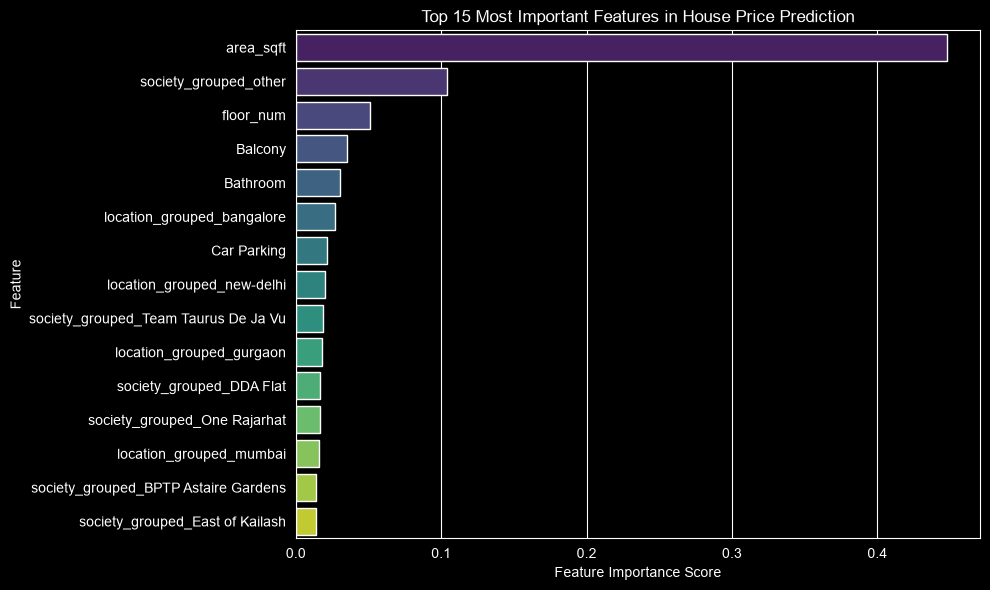

Model pipeline successfully saved to '../house_price.joblib'!


In [79]:
# Extract Feature Importances from Random Forest Pipeline
rf_model = rf_pipeline.named_steps['reg']
preprocessor_step = rf_pipeline.named_steps['prep']

# Get encoded feature names
cat_cols_encoded = preprocessor_step.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_features, cat_cols_encoded])

importances = rf_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances}).sort_values('Importance', ascending=False)

# Plot Top 15 Features
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp_df.head(15), x='Importance', y='Feature', palette='viridis', legend=False)
plt.title('Top 15 Most Important Features in House Price Prediction')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

# Export Trained Pipeline
joblib.dump(rf_pipeline, '../house_price.joblib')
print("Model pipeline successfully saved to '../house_price.joblib'!")

--- Random Forest Regressor  ---
MAE : 0.2499021456585879
RMSE: 0.6729033464065144
R²  : 0.8286937495300835

--- Decision Tree Regressor ---
MAE : 0.4066869558321164
RMSE: 0.8420563364413617
R²  : 0.7317435767327409


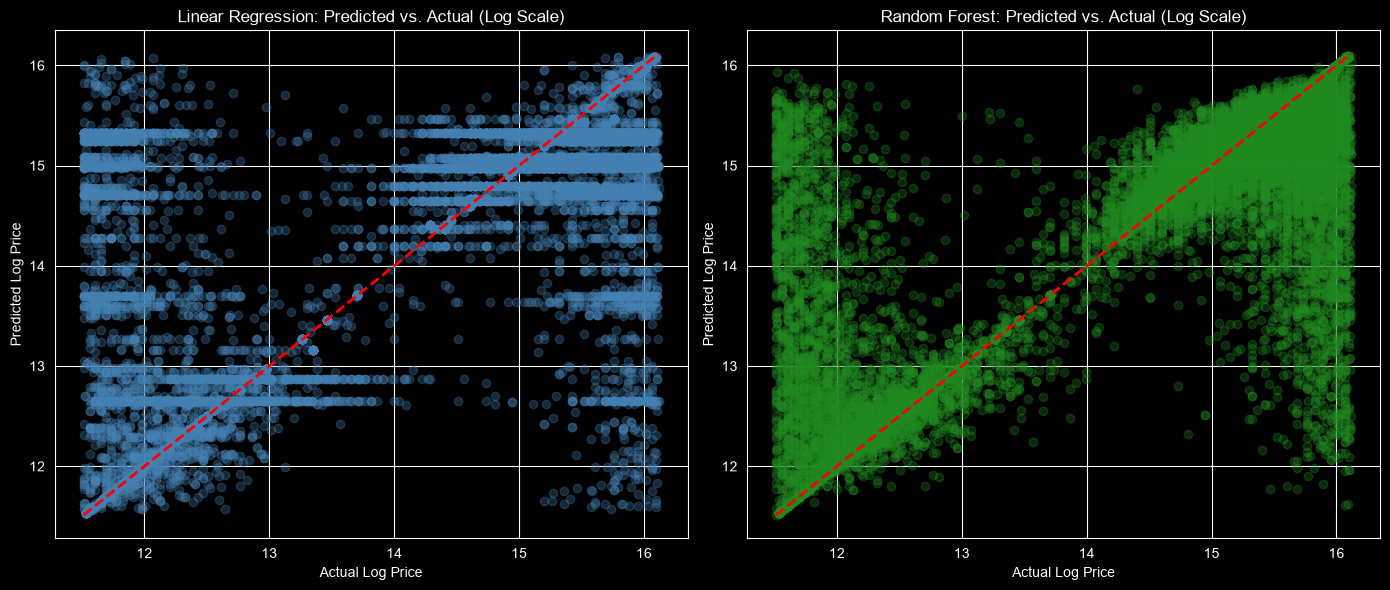

,Model,MAE (Log),RMSE (Log),Test R²
0,Random Forest Regressor,0.406687,0.842056,0.731744
1,Decision Tree Regressor,0.249902,0.672903,0.828694



Running 5-Fold Cross-Validation on Random Forest...
5-Fold CV R² Scores: [ 0.7054  0.2965  0.8453  0.0665 -0.0243]
Mean CV R² Score  : 0.3779 (+/- 0.3438)


In [80]:
# Print Standard Metrics
rf_pred = rf_pipeline.predict(X_test)
dt_pred = dt_pipeline.predict(X_test)

print("--- Random Forest Regressor  ---")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE:", root_mean_squared_error(y_test, rf_pred))
print("R²  :", r2_score(y_test, rf_pred))

print("\n--- Decision Tree Regressor ---")
print("MAE :", mean_absolute_error(y_test, dt_pred))
print("RMSE:", root_mean_squared_error(y_test, dt_pred))
print("R²  :", r2_score(y_test, dt_pred))

# Predicted vs Actual Scatter Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest
axes[1].scatter(y_test, rf_pred, alpha=0.3, color='forestgreen')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title('Random Forest: Predicted vs. Actual (Log Scale)')
axes[1].set_xlabel('Actual Log Price')
axes[1].set_ylabel('Predicted Log Price')

# Decision Tree
axes[0].scatter(y_test, dt_pred, alpha=0.3, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Linear Regression: Predicted vs. Actual (Log Scale)')
axes[0].set_xlabel('Actual Log Price')
axes[0].set_ylabel('Predicted Log Price')



plt.tight_layout()
plt.show()

# Model Comparison Table
comp_df = pd.DataFrame({
    'Model': ['Random Forest Regressor', 'Decision Tree Regressor'],
    'MAE (Log)': [mean_absolute_error(y_test, dt_pred), mean_absolute_error(y_test, rf_pred)],
    'RMSE (Log)': [root_mean_squared_error(y_test, dt_pred), root_mean_squared_error(y_test, rf_pred)],
    'Test R²': [r2_score(y_test, dt_pred), r2_score(y_test, rf_pred)]
})

display(comp_df)

# 5-Fold Cross-Validation on Random Forest
print("\nRunning 5-Fold Cross-Validation on Random Forest...")
rf_cv_scores = cross_val_score(rf_pipeline, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f"5-Fold CV R² Scores: {np.round(rf_cv_scores, 4)}")
print(f"Mean CV R² Score  : {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

In [81]:
#Winner Selection

#Winner:** `RandomForestRegressor`

#Justification:**
# The Random Forest Regressor outperforms the Decision Tree Regressor across all evaluation metrics, achieving an R² score of 0.8287 compared to the Decision Tree Regressor's 0.7317. It also achieves a lower MAE (0.2499 vs. 0.4067) and RMSE (0.6729 vs. 0.8421), indicating more accurate and consistent predictions with smaller average and overall errors. These results demonstrate that the Random Forest model generalizes better to unseen data, while the Decision Tree Regressor is more prone to overfitting. The superior performance of the Random Forest Regressor is due to its ensemble learning approach, which combines the predictions of multiple decision trees to reduce variance and better capture the complex relationships between numerical features such as area and categorical features such as location.

In [86]:
#Export the winning Random Forest pipeline
joblib.dump(rf_pipeline, "house_price.pkl")
print("Model successfully saved as 'house_price.pkl'")

# Reload and predict a single sample
loaded_model = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
reloaded_pred_log = loaded_model.predict(sample)[0]
reloaded_pred_price = np.expm1(reloaded_pred_log)

print(f"Reloaded prediction (Log Scale): {reloaded_pred_log:.4f}")
print(f"Reloaded prediction (Rupees):    ₹{reloaded_pred_price:,.2f}")

# Export locations for frontend dropdown
allowed_locations = sorted(data_clean["location_grouped"].unique().tolist())
with open("locations.json", "w") as f:
    json.dump(allowed_locations, f)
print(f"Saved {len(allowed_locations)} unique locations to 'locations.json'")

# Version pinning check
print(f"\nScikit-Learn Version: {sklearn.__version__}")

Model successfully saved as 'house_price.pkl'
Reloaded prediction (Log Scale): 12.2115
Reloaded prediction (Rupees):    ₹201,087.85
Saved 51 unique locations to 'locations.json'

Scikit-Learn Version: 1.9.0
